## Phase 1: Exploratory Data Analysis

In [1]:
import pandas as pd        
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns      

df = pd.read_csv("../data/train.csv")

print(df.head())
print(df.shape)
df.info()

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [2]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [3]:
print("Skewness:", df['SalePrice'].skew())
# Skewness = 1.88, well above 1 -> strongly right-skewed.
# Most houses cluster at moderate prices, but a handful of expensive outliers 
# create a long tail toward high values, pulling this number up from 0.

Skewness: 1.8828757597682129


In [4]:
print("Log-skewness:", np.log1p(df['SalePrice']).skew())
# Log-skewness = 0.12, close to 0 -> nearly symmetric.
# log1p compressed the long right tail, confirming we should train
# on log1p(SalePrice) instead of raw SalePrice, and reverse with expm1() 
# on predictions before submitting.

Log-skewness: 0.12134661989685333


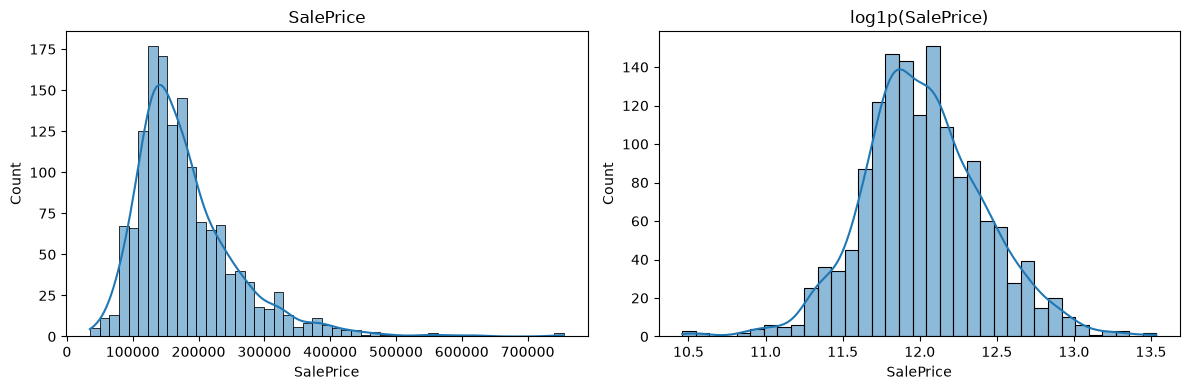

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# creates one figure with 1 row, 2 columns of side-by-side empty plots (12x4 inches total)
# fig = the whole figure, axes = list of the two individual plot areas [axes[0], axes[1]]
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
# draws a histogram of SalePrice (bars = how many houses fall in each price range)
# kde=True overlays a smooth curve showing the estimated distribution shape
# ax=axes[0] draws it into the left subplot created above, instead of a new figure
axes[0].set_title('SalePrice')
#sets the title of the left subplot
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1])
# draws a histogram of SalePrice (bars = how many houses fall in each price range)
# kde=True overlays a smooth curve showing the estimated distribution shape
# ax=axes[1] draws it into the right subplot created above, instead of a new figure
axes[1].set_title('log1p(SalePrice)')
#sets the title of the right subplot
plt.tight_layout()
# automatically adjusts spacing between the two subplots and their titles/labels
# so nothing overlaps or gets cut off at the edges
plt.show()
#displays the figure with the two subplots

## Why we checked skewness and plotted the distributions

**Goal:** decide whether to train the model on raw `SalePrice` or a transformed version.

**Why it matters:** many regression models perform better when the target variable
is roughly symmetric (bell-shaped). A skewed target — where a few extreme values
create a long tail — can distort what the model learns as "typical," since those
extreme values disproportionately affect the loss function.

**What we found:**
- `.describe()` on `SalePrice` showed mean ($180,921) > median ($163,000) — 
  an early sign of right-skew (a small number of expensive houses pulling the average up).
- `.skew()` confirmed this numerically: raw `SalePrice` skewness = **1.88** 
  (strongly right-skewed; anything above 1 is considered highly skewed).
- Applying `log1p()` (log(1 + x)) compresses large values much more than small ones,
  a standard fix for right-skewed data.
- After the transform: `log1p(SalePrice)` skewness = **0.12** (nearly symmetric).

**Visual confirmation:** the side-by-side histograms showed this directly —
raw `SalePrice` has a tall cluster of houses at moderate prices with a long thin
tail stretching toward $750k; `log1p(SalePrice)` looks close to a normal bell curve.

**Decision:** train the model on `log1p(SalePrice)` instead of raw `SalePrice`.
Remember to reverse the transform with `np.expm1()` on predictions before
submitting, to convert back to real dollar values.

In [6]:
# see which columns have missing values, sorted by how many
missing = df.isnull().sum().sort_values(ascending=False)
#df.isnull() : goes through the dataframe and checks if each value is null or not, returns a boolean dataframe, True if null, False if not null
#sum() : sums up the boolean values for each column, True is treated as 1 and False as 0, so it gives the count of missing values for each column
#sort_values(ascending=False) : sorts the resulting series of missing values in descending order, so the columns with the most missing values come first
missing = missing[missing > 0]
#missing[missing > 0] : filters the series to only include columns that have missing values, i.e., where the count of missing values is greater than 0
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [7]:
numeric_df = df.select_dtypes(include=[np.number])
# selects only the numeric columns from df (ints and floats), 
# dropping text/categorical columns since correlation only works on numbers

corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
# .corr() computes the correlation between every pair of numeric columns,
# returning a full correlation matrix (columns x columns)
# ['SalePrice'] pulls out just one column of that matrix — 
# each numeric feature's correlation with SalePrice specifically
# .sort_values(ascending=False) sorts from strongest positive to weakest/negative

corr
# displays the sorted correlations

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

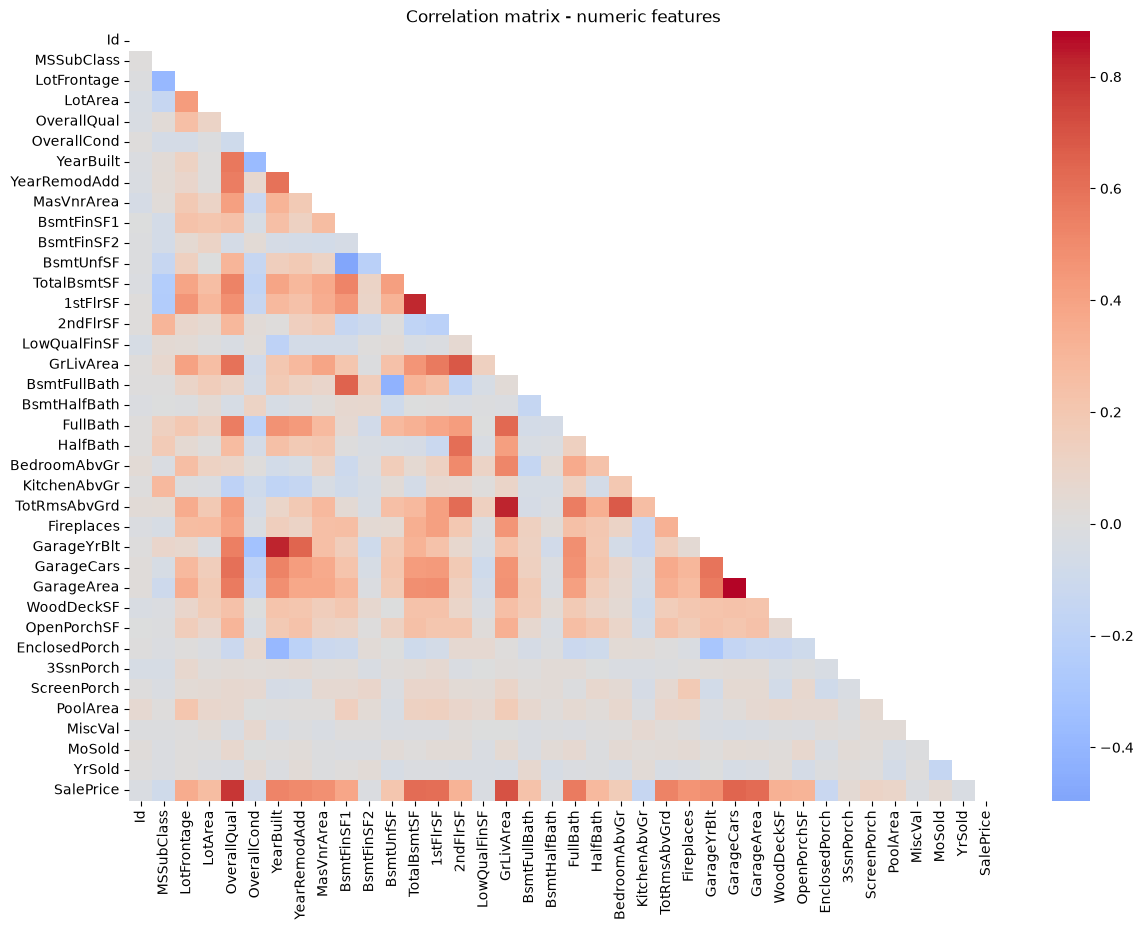

In [8]:
corr_matrix = numeric_df.corr()
# compute the correlation matrix once and store it

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# np.ones_like(...) creates a grid the same shape as corr_matrix, all True
# np.triu(...) keeps only the upper triangle (including the diagonal) as True,
# sets the lower triangle to False
# mask = this grid; True means "hide this cell" when passed to heatmap

plt.figure(figsize=(14, 10))
# sets the figure size to 14 inches wide, 10 inches tall

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, mask=mask)
# draws the heatmap using the precomputed corr_matrix
# mask=mask hides the diagonal (always 1.0, meaningless) and the upper triangle
# (a mirrored duplicate of the lower triangle) — leaves only the unique values visible

plt.title('Correlation matrix - numeric features')
plt.show()

In [9]:
results = []
# empty list that will collect one entry (dictionary) per categorical column

cat_cols = df.select_dtypes(include='str').columns
for col in cat_cols:
    means = df.groupby(col)['SalePrice'].mean()
    # splits the dataframe into groups by category, then averages SalePrice within each group
    # (same as before)

    spread = means.max() - means.min()
    # gap between the highest-average-price category and lowest-average-price category

    n_categories = df[col].nunique()
    # counts how many unique categories exist in this column
    # (e.g. Neighborhood might have ~25, a column with only 2 possible values would show 2)

    results.append({'column': col, 'spread': spread, 'n_categories': n_categories})
    # adds one row of info for this column — its name, its spread, and its category count —
    # to the results list, as a dictionary

summary = pd.DataFrame(results).sort_values('spread', ascending=False)
# converts the list of dictionaries into a proper table (one row per column)
# sorts that table by spread, largest gap first, so the most price-relevant
# categorical columns appear at the top

summary

,column,spread,n_categories
38,PoolQC,288010.000000,3
18,ExterQual,279375.747253,4
14,RoofMatl,253250.000000,8
8,Neighborhood,236718.846485,25
10,Condition2,228250.000000,8
30,KitchenQual,222989.464872,4
16,Exterior2nd,214000.000000,16
21,BsmtQual,211349.012751,4
32,FireplaceQu,207948.350000,5
15,Exterior1st,191000.000000,15


In [10]:
df['Neighborhood'].value_counts()
#good for plot

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [11]:
df['RoofMatl'].value_counts() 
#not good for plot, 98% are CompShg

RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

In [12]:
df['ExterQual'].value_counts()
#good for plot

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

In [13]:
df['KitchenQual'].value_counts()
#good for plot

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

In [15]:
df['FireplaceQu'].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [16]:
df['Exterior2nd'].value_counts()

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

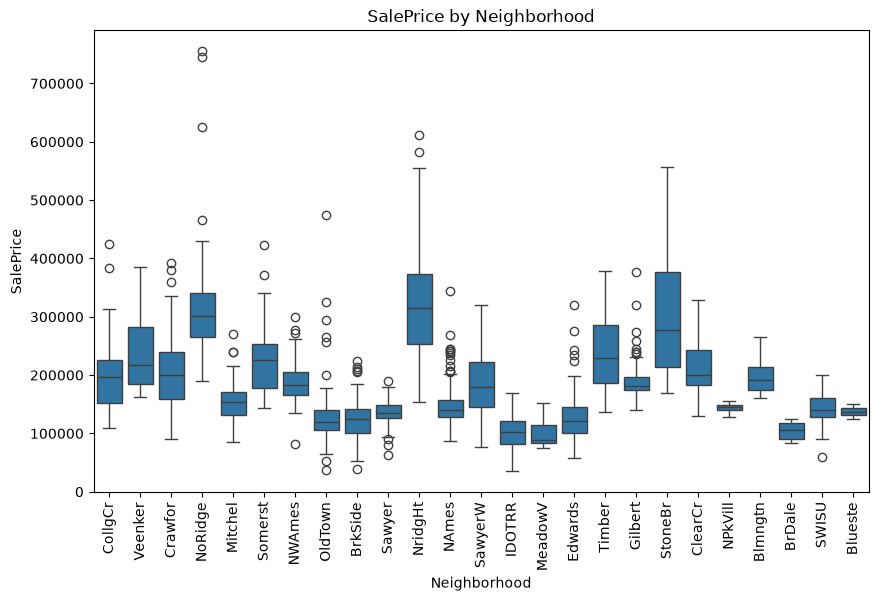

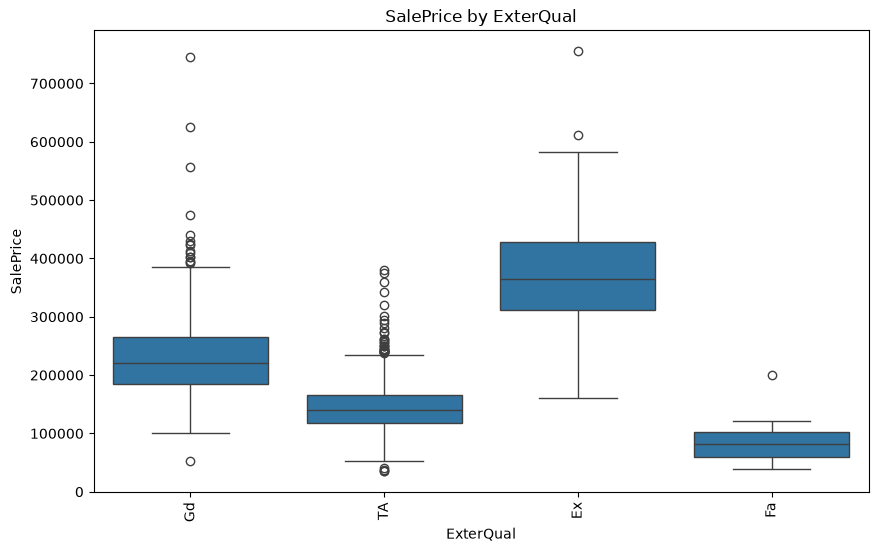

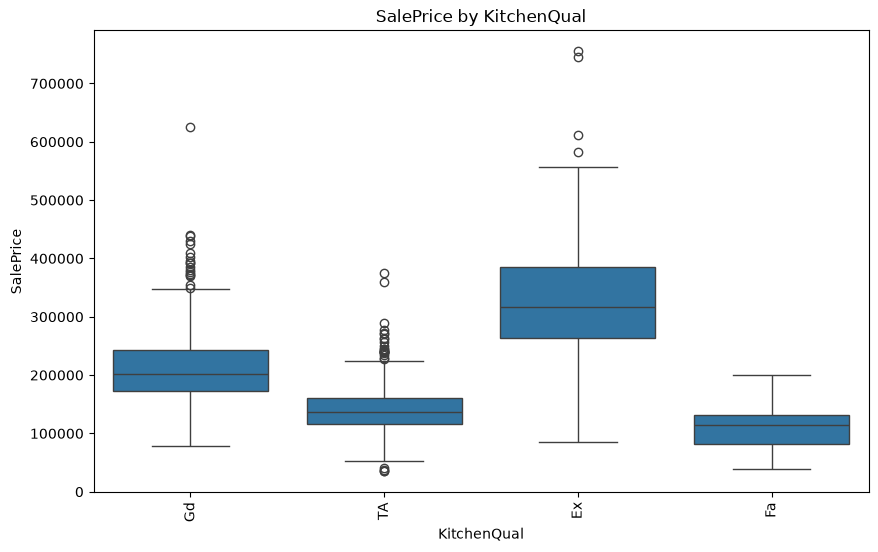

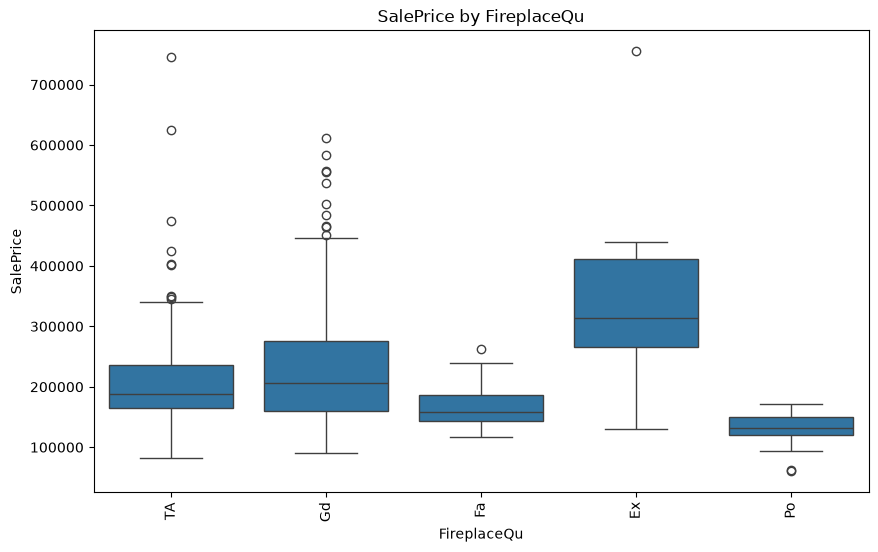

In [17]:
for col in ['Neighborhood', 'ExterQual', 'KitchenQual', 'FireplaceQu']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.xticks(rotation=90)
    plt.title(f'SalePrice by {col}')
    plt.show()

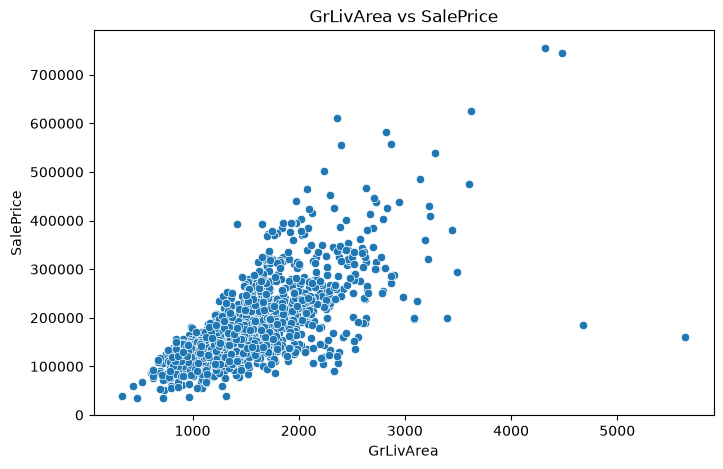

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('GrLivArea vs SalePrice')
plt.show()

In [19]:
df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


# Phase 1: EDA — Summary

## Target variable — SalePrice
- Right-skewed (skew 1.88); log1p(SalePrice) is nearly symmetric (skew 0.12)
- Decision: train on log1p(SalePrice), reverse with expm1() before submitting

## Missing values
- 19 columns with nulls, categorized as documented "NA=no feature" vs genuinely missing
- Cross-referenced against data_description.txt

## Numeric correlation
- Correlation of numeric features vs SalePrice: strongest are OverallQual (0.79),
  GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61)
- Full correlation heatmap: flagged possible multicollinearity 
  (e.g. GarageCars/GarageArea, TotalBsmtSF/1stFlrSF)

## Categorical features vs SalePrice
- Screened all 43 categorical columns via spread-of-average-price + category counts
- Verified with .value_counts() to catch false positives from tiny categories
  (rejected RoofMatl, Condition2, Exterior1st, Exterior2nd — dominated by 1-2 categories
  or noisy tails)
- Confirmed strong, reliable signals via boxplot: Neighborhood, ExterQual, 
  KitchenQual, FireplaceQu — all show clear, well-populated, sensible patterns

## Outlier check
- GrLivArea vs SalePrice scatter revealed 2 outlier rows (index 523, 1298):
  very large living area, unusually low price, both SaleCondition='Partial'
  (unfinished new construction) — flagged for removal in Phase 2


## Phase 2: Data Cleaning

In [20]:
df[df['PoolQC'].isnull()]['PoolArea'].describe()

count    1453.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: PoolArea, dtype: float64

In [35]:
df['PoolQC'] = df['PoolQC'].fillna('None')

## Analyzing null values

- PoolQC : Pool Quality, NA = No Pool (verified: PoolArea = 0 for all nulls)
- MiscFeature : NA = None (no elevator, 2nd garage, shed 100+ ft, tennis court, etc.)
- Alley : NA = No alley access
- Fence : NA = No Fence
- FireplaceQu : NA = No Fireplace
- GarageType/GarageFinish/GarageQual/GarageCond : NA = No Garage
- BsmtQual/BsmtCond/BsmtExposure/BsmtFinType1/BsmtFinType2 : NA = No Basement
- LotFrontage : not a documented NA code, genuinely missing → impute median by Neighborhood
- GarageYrBlt : numeric, no garage → fill with 0 or YearBuilt
- MasVnrArea : numeric, likely no veneer → fill with 0
- MasVnrType : "None" is already a valid category (separate from NA) → verify against MasVnrArea before filling
- Electrical : NA not documented, only 1 missing row → impute with mode

In [21]:
df[df['MasVnrType'].isnull()]['MasVnrArea'].describe() 
# df['MasVnrType'].isnull() : returns a boolean series indicating which rows have missing values in the 'MasVnrType' column
# df[df['MasVnrType'].isnull()] : filters the dataframe to only include rows where 'MasVnrType' is null
# ['MasVnrArea'].describe() : computes summary statistics for the 'MasVnrArea' column of the filtered dataframe,
# This will give insights into the distribution of 'MasVnrArea' values for those specific rows.

count    864.000000
mean       1.094907
std       18.569659
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      344.000000
Name: MasVnrArea, dtype: float64

In [22]:
df[df['MasVnrType'].isnull() & (df['MasVnrArea'] > 0)][['MasVnrType', 'MasVnrArea']]
#df['MasVnrArea'] > 0 : returns a boolean series indicating which rows have 'MasVnrArea' greater than 0
# & : logical AND operator, combines the two boolean series to find rows where both conditions are true
#[['MasVnrType', 'MasVnrArea']] : selects only the 'MasVnrType' and 'MasVnrArea' columns from the filtered dataframe

,MasVnrType,MasVnrArea
624,NaN,288.0
773,NaN,1.0
1230,NaN,1.0
1300,NaN,344.0
1334,NaN,312.0


## Explaining above result

From 872 rows with an unknown veneer type, 864 had a real area value recorded (most were 0).
The remaining 8 rows had no area value either (missing both columns).
Of the 864, a small number (5) had a nonzero area — these are inconsistent rows,
found separately by filtering for MasVnrArea > 0

In [23]:
mode_type = df['MasVnrType'].mode()[0]
#df['MasVnrType'].mode() : calculates the mode (most frequently occurring value) of the 'MasVnrType' column, returns a Series
#[0] : accesses the first element of the mode Series, which is the most common value
different_values = df['MasVnrType'].isnull() & (df['MasVnrArea'] > 0) 
# resulting in a boolean series that identifies rows with missing 'MasVnrType' and 'MasVnrArea' greater than 0
df.loc[different_values, 'MasVnrType'] = mode_type
#df.loc[different_values, 'MasVnrType'] : uses the .loc indexer to access the rows in the dataframe where different_values is True and specifically targets the 'MasVnrType' column
# = mode_type : assigns the value of mode_type to the 'MasVnrType'

In [24]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
#fill any remaining missing values in the 'MasVnrType' column with the string 'None', indicating that there is no masonry veneer type for those entries
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
#fill any remaining missing values in the 'MasVnrArea' column with 0, indicating that there is no masonry veneer area for those entries

In [25]:
df[['MasVnrType', 'MasVnrArea']].isnull().sum()
#there are no null values anymore in the 'MasVnrType' and 'MasVnrArea' columns, as indicated by the sum of null values being 0 for both columns

MasVnrType    0
MasVnrArea    0
dtype: int64

In [ ]:
#Self-check : MasVntType and MasVnrArea have no null values
df[['MasVnrType', 'MasVnrArea']].isnull().sum()

MasVnrType    0
MasVnrArea    0
dtype: int64

In [30]:
df[df['FireplaceQu'].isnull()]['Fireplaces'].describe() 

count    690.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Fireplaces, dtype: float64

## Explaining above results

Unlike MasVnrType/MasVnrArea, all rows where FireplaceQu is null have Fireplaces = 0 
(not missing, just zero) — meaning no fireplace, consistently, with no exceptions.
So we simply fill FireplaceQu's null values with the string 'None'.

In [31]:
df['FireplaceQu'].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [32]:
#since fireplaceQu is a categorical variable, we will fill null values with None
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

In [33]:
#self-check : FireplaceQu has no null values
df['FireplaceQu'].isnull().sum()

np.int64(0)

In [36]:
df[df['MiscFeature'].isnull()]['MiscVal'].describe()

count    1406.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: MiscVal, dtype: float64

In [37]:
df['MiscFeature'] = df['MiscFeature'].fillna('None')

In [39]:
df['Alley'].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [40]:
df['Alley'] = df['Alley'].fillna('None')

In [ ]:
#self-check : Alley has no null values
df['Alley'].value_counts()

Alley
None    1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [42]:
df['Fence'].value_counts()

Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

In [43]:
df['Fence'] = df['Fence'].fillna('None')

In [ ]:
#self-check : Fence has no null values
df['Fence'].value_counts()

Fence
None     1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

In [ ]:
garage_cols = ['GarageQual', 'GarageFinish', 'GarageType', 'GarageYrBlt', 'GarageCond' ]
df[garage_cols].isnull().sum()
# this shows how many null values are missing in each column

GarageQual      81
GarageFinish    81
GarageType      81
GarageYrBlt     81
GarageCond      81
dtype: int64

In [ ]:
df[garage_cols].isnull().sum(axis=1).value_counts()
# isnull() flags nulls, sum(axis=1) counts nulls per ROW (across the 5 columns) instead of per column
# only seeing 0s and 5s confirms all 5 garage columns go null together, per house

0    1379
5      81
Name: count, dtype: int64

In [47]:
cat_garage_cols = ['GarageQual', 'GarageFinish', 'GarageType', 'GarageCond' ]
df[cat_garage_cols] = df[cat_garage_cols].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [48]:
df[garage_cols].isnull().sum()

GarageQual      0
GarageFinish    0
GarageType      0
GarageYrBlt     0
GarageCond      0
dtype: int64

In [50]:
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[bsmt_cols].isnull().sum(axis=1).value_counts()

0    1421
5      37
1       2
Name: count, dtype: int64

In [ ]:
df[df[bsmt_cols].isnull().sum(axis=1) == 1][bsmt_cols]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
332,Gd,TA,No,GLQ,NaN
948,Gd,TA,NaN,Unf,Unf


In [52]:
df.loc[332, 'BsmtFinType2'] = 'Unf'
df.loc[948, 'BsmtExposure'] = df['BsmtExposure'].mode()[0]

In [67]:
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[bsmt_cols] = df[bsmt_cols].fillna('None')

In [53]:
df[df['LotFrontage'].isnull()]['LotArea'].describe()

count       259.000000
mean      13137.370656
std       16215.264451
min        1974.000000
25%        8065.500000
50%       10624.000000
75%       13018.500000
max      164660.000000
Name: LotArea, dtype: float64

In [54]:
df[['LotFrontage', 'LotArea']].corr()

,LotFrontage,LotArea
LotFrontage,1.000000,0.426095
LotArea,0.426095,1.000000


In [55]:
df.groupby('Neighborhood')['LotFrontage'].median().sort_values(ascending=False)

Neighborhood
NoRidge    91.0
NridgHt    88.5
Timber     85.0
NWAmes     80.0
ClearCr    80.0
Crawfor    74.0
Somerst    73.5
NAmes      73.0
Mitchel    73.0
Sawyer     71.0
CollgCr    70.0
Veenker    68.0
SawyerW    66.5
Edwards    65.5
Gilbert    65.0
StoneBr    61.5
IDOTRR     60.0
OldTown    60.0
SWISU      60.0
BrkSide    52.0
Blmngtn    43.0
NPkVill    24.0
Blueste    24.0
BrDale     21.0
MeadowV    21.0
Name: LotFrontage, dtype: float64

In [ ]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
# df.groupby('Neighborhood') splits the dataframe into separate groups, one per neighborhood
# ['LotFrontage'] focuses only on the LotFrontage column within each group
# .transform(...) applies a function to each group separately, but returns a result
#   the same length as the original column, so it can be assigned straight back
# lambda x: x.fillna(x.median()) : for each neighborhood group (x), fills any nulls
#   in that group using THAT group's own median LotFrontage (not the overall dataset median)
# result: a missing frontage in NAmes gets filled with NAmes' median, 
#   a missing value in Somerst gets filled with Somerst's median, etc

In [58]:
df['LotFrontage'].isnull().sum()

np.int64(0)

In [65]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [70]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [72]:
df['is_outlier'] = df.index.isin([523, 1298])
# marks the 2 known outlier rows (very large GrLivArea, unusually low SalePrice,
# both with SaleCondition = 'Partial' - unfinished new construction at time of sale)
# instead of dropping them now - keeps the option open to compare model performance
# with vs without them later in Phase 5, rather than losing that ability permanently

In [74]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

In [76]:
df['MSSubClass'].describe()

count     1460
unique      15
top         20
freq       536
Name: MSSubClass, dtype: object

In [78]:
print(df.isnull().sum().sum())  # should be 0
print(df.shape)  # should be (1460, 82)
print(df['MSSubClass'].dtype)  # should be object

0
(1460, 82)
str


# Phase 2: Data Cleaning — Summary

## Missing values (19 columns, all resolved)
- Documented "NA = no feature" -> filled with 'None': PoolQC, MiscFeature, Alley, Fence,
  FireplaceQu, Garage(Type/Finish/Qual/Cond), Bsmt(Qual/Cond/Exposure/FinType1/FinType2)
- MasVnrType: 5 inconsistent rows (null type, nonzero area) filled with mode ('BrkFace');
  remaining nulls filled 'None'. MasVnrArea filled with 0.
- Garage group: verified all 5 columns null together (row-level check, axis=1) for the
  same 81 houses. GarageYrBlt filled with 0 (numeric, kept honest rather than faking
  a garage year with YearBuilt) — noted for special handling in Phase 3.
- Basement group: verified mostly consistent (37 rows null together = no basement),
  but found 2 exceptions (rows 332, 948) with a real basement missing one column each —
  fixed individually (BsmtFinType2 -> 'Unf', BsmtExposure -> mode) before the group fill.
- LotFrontage: genuinely missing (not a documented NA). Verified moderate correlation
  with LotArea (0.43), imputed with median grouped by Neighborhood.
- Electrical: 1 row, genuinely missing, imputed with mode.

## Outliers
- Identified 2 outlier rows (523, 1298) in Phase 1 (GrLivArea vs SalePrice) — both
  SaleCondition = 'Partial' (unfinished new construction).
- Flagged with an is_outlier column instead of dropping, to allow comparing model
  performance with vs without them in Phase 5.

## Dtype fixes
- MSSubClass: converted from numeric to string — values are category codes 
  (dwelling type), not a real numeric scale.

## Final verification
- df.isnull().sum().sum() == 0
- df.shape == (1460, 82)

## Phase 3: Feature Engineering